In [1]:
%load_ext autoreload
%autoreload 2

In [18]:
from pass_at_k import pass_at_k_rates
import math
from pass_at_k import (
    BetaBinomialPassAtK,
    NPMLEBinomialPassAtK,
    BetaMixtureNPMLEPassAtK,
    bootstrap_pass_at_k_ci,
    kazdan_sampling,
    uniform_sampling,
)
import numpy as np

import pickle
with open('monkey_business.pkl', 'rb') as f:
    data_dict = pickle.load(f)

# k_values = np.array([1, 2, 5, 10, 20, 50, 100, 200])
# k_values = np.array([1, 2, 5, 10, 20, 50])
k_values = np.arange(10, 1000, 10)
total_budget = 10000

def compute(data, k_values, total_budget, sampler="uniform"):
    mvue_pass_at_k = pass_at_k_rates(data, k_values)
    if sampler == "kazdan":
        data = kazdan_sampling(data, total_budget)
    elif sampler == "uniform":
        data = uniform_sampling(
            data,
            per_problem_budget=math.ceil(total_budget / data.shape[0])
        )

    est = BetaBinomialPassAtK(verbose=True)

    est.fit(data['successes'], data['attempts'])
    est_int = est.predict(k_values, method="integrated", bias_correct=False)
    est_posterior = est.predict(k_values, method="posterior")

    # est_npmle = NPMLEBinomialPassAtK(verbose=False)
    # est_npmle.fit(data['successes'], data['attempts'])
    # est_npmle_pass = est_npmle.predict(k_values)

    # est_npmle_plugin = est_npmle.predict(k_values, method="plugin", bias_correct=False)
    # est_npmle_plugin_bc = est_npmle.predict(k_values, method="plugin", bias_correct=True)

    # est_beta_mixture_npmle = BetaMixtureNPMLEPassAtK(verbose=False, nu=8.0)
    # est_beta_mixture_npmle.fit(data['successes'], data['attempts'])
    # est_beta_mixture_npmle_integrated = est_beta_mixture_npmle.predict(k_values, method='integrated')
    # est_beta_mixture_npmle_posterior = est_beta_mixture_npmle.predict(k_values, method='posterior')

    # est_npmle_reg = NPMLEBinomialPassAtK(verbose=False, reg_alpha=0.001)
    # est_npmle_reg.fit(data['successes'], data['attempts'])
    # est_npmle_reg_pass = est_npmle_reg.predict(k_values)

    # est_npmle_reg_plugin = est_npmle_reg.predict(k_values, method="plugin", bias_correct=False)
    # est_npmle_reg_plugin_bc = est_npmle_reg.predict(k_values, method="plugin", bias_correct=True)

    boot_int, lower_int, upper_int = bootstrap_pass_at_k_ci(
        lambda: BetaBinomialPassAtK(verbose=False),
        data['successes'], data['attempts'],
        k_values, n_bootstraps=1000,
        predict_configs=[{"method": "integrated"}]
    )
    fit = {
        "estimate": est_int,
        "estimate_boot": boot_int,
        "estimate_posterior": est_posterior,
        "mvue": mvue_pass_at_k,
        "lower_ci": lower_int,
        "upper_ci": upper_int,
        # "npmle": est_npmle_pass,
        # "beta_mixture_integrated": est_beta_mixture_npmle_integrated,
        # "beta_mixture_posterior": est_beta_mixture_npmle_posterior,
        # # "efron_g": est_efron_g_pass,
        # "npmle_plugin": est_npmle_plugin,
        # "npmle_plugin_bc": est_npmle_plugin_bc,
        # "npmle_reg": est_npmle_reg_pass,
        # "npmle_reg_plugin": est_npmle_reg_plugin,
        # "npmle_reg_plugin_bc": est_npmle_reg_plugin_bc,
    }

    return fit


In [20]:
import math
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

DATASET_ID = "ScalingIntelligence/monkey_business"
SPLIT = "test"

cfg_to_data = data_dict

cfg_names = list(cfg_to_data.keys())
n_cfg = len(cfg_names)

# Precompute results per config
results = {}
for cfg in cfg_names:
    oracle_data = cfg_to_data[cfg]['data']
    fit = compute(oracle_data, k_values, total_budget, sampler="uniform")

    successes_oracle = np.sum(oracle_data, axis=1)
    attempts_oracle = np.full(oracle_data.shape[0], oracle_data.shape[1], dtype=np.int64)
    est_oracle = BetaBinomialPassAtK(verbose=False).fit(successes_oracle, attempts_oracle)
    alpha_oracle, beta_oracle = est_oracle.alpha_, est_oracle.beta_

    p_hat = successes_oracle / attempts_oracle.astype(float)
    p_hat_pos = p_hat[p_hat > 0]

    results[cfg] = {
        "fit": fit,
        "alpha": alpha_oracle,
        "beta": beta_oracle,
        "p_hat_pos": p_hat_pos,
    }


/home/dkp45/inference-scaling-law/pass_at_k.py:254: RuntimeWarning: invalid value encountered in subtract
  log_lik = betaln(successes + alpha, attempts - successes + beta) - betaln(alpha, beta)
/home/dkp45/inference-scaling-law/pass_at_k.py:252: RuntimeWarning: overflow encountered in exp
  alpha = np.exp(log_alpha)
/home/dkp45/inference-scaling-law/pass_at_k.py:253: RuntimeWarning: overflow encountered in exp
  beta = np.exp(log_beta)
/home/dkp45/inference-scaling-law/pass_at_k.py:299: RuntimeWarning: overflow encountered in exp
  return np.exp(betaln(a, b + k_values) - betaln(a, b))
/home/dkp45/miniconda3/envs/trl-nano/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


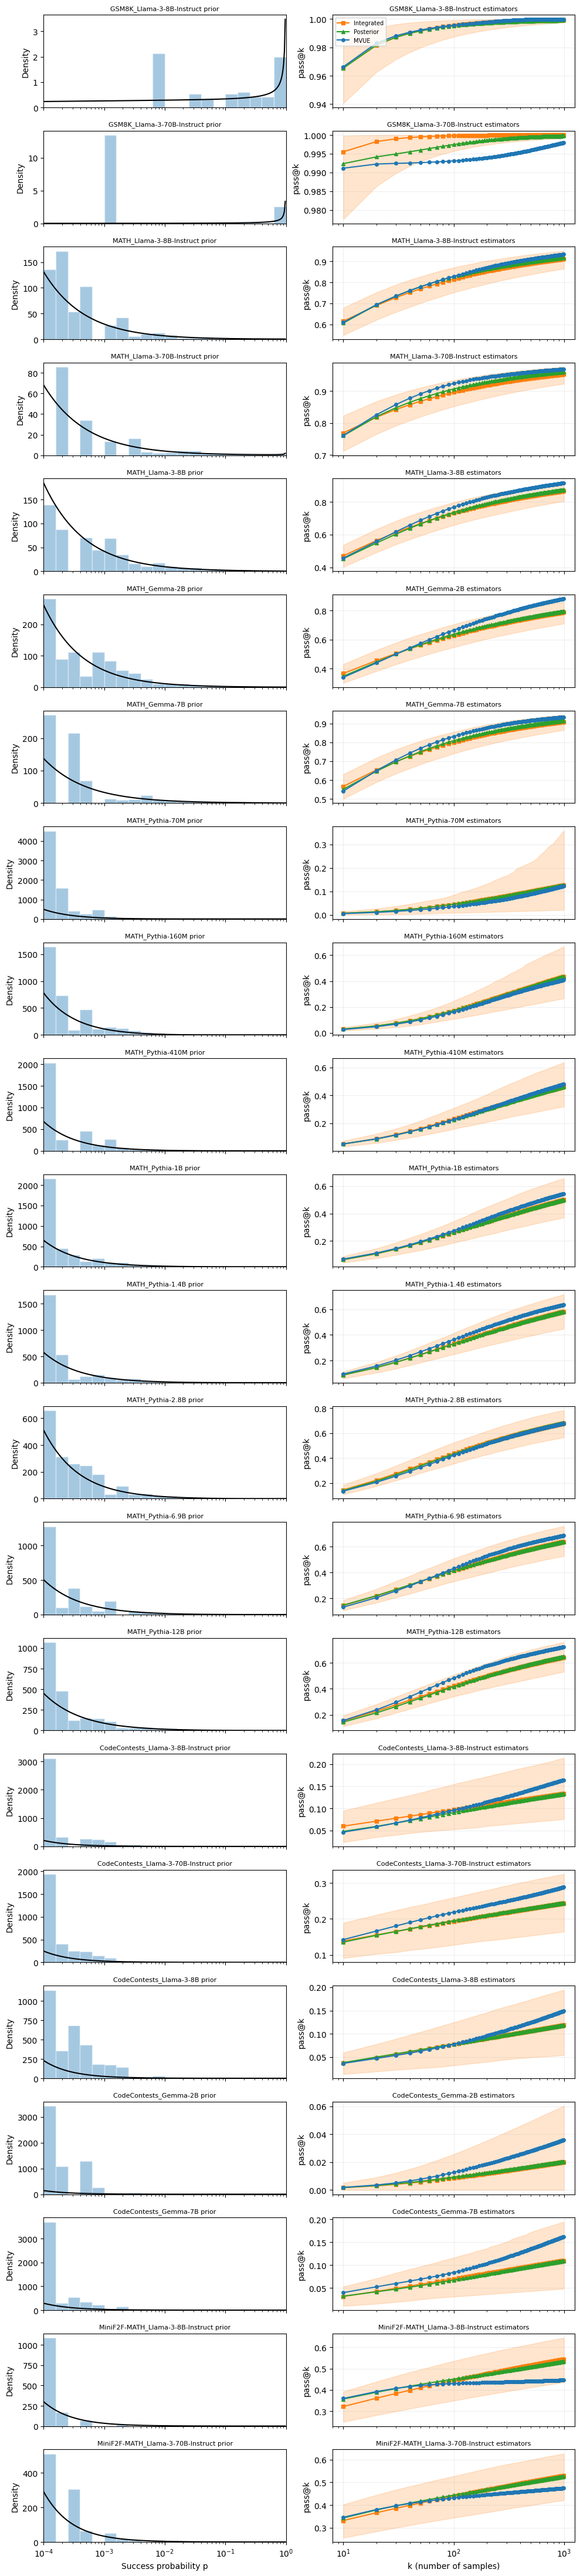

In [22]:
# One big figure with n_cfg rows and 2 columns (20 axes if n_cfg=10)
fig, axes = plt.subplots(n_cfg, 2, figsize=(10, max(6, 2.0 * n_cfg)), sharex="col")

# If only one config, make axes 2D-compatible
if n_cfg == 1:
    axes = np.array([axes])

x = np.logspace(-4, 0, 300)

for row, cfg in enumerate(cfg_names):
    res = results[cfg]
    fit = res["fit"]
    p_hat_pos = res["p_hat_pos"]

    ax_prior = axes[row, 0]
    ax_est = axes[row, 1]

    # Left: prior (hist + Beta fit)
    ax_prior.hist(
        p_hat_pos,
        bins=np.logspace(-4, 0, 21),
        density=True,
        alpha=0.4,
        color="C0",
        edgecolor="white",
    )
    ax_prior.plot(
        x,
        beta_dist.pdf(x, res["alpha"], res["beta"]),
        "k-",
        linewidth=1.5,
    )
    ax_prior.set_xscale("log")
    if row == n_cfg - 1:
        ax_prior.set_xlabel("Success probability p")
    ax_prior.set_ylabel("Density")
    ax_prior.set_xlim(1e-4, 1)
    ax_prior.set_title(f"{cfg} prior", fontsize=8)

    # Right: estimators vs MVUE
    ax_est.fill_between(
        k_values,
        fit["lower_ci"],
        fit["upper_ci"],
        alpha=0.2,
        color="C1",
    )
    estimator_specs = [
        ("estimate", "Integrated", "s-", "C1"),
        ("estimate_posterior", "Posterior", "^-", "C2"),
        ("mvue", "MVUE", "o-", "C0"),
        ("beta_mixture_posterior", "Beta Mixture Posterior", "v-", "C3"),
        ("beta_mixture_integrated", "Beta Mixture Integrated", "^-", "C4"),
        # ("npmle", "NPMLE", "^-", "C2"),
        # ("npmle_mixture", "NPMLE Mixture", "v-", "C3"),
        # # ("efron_g", "Efron G", "^-", "C4"),
        # ("npmle_plugin", "NPMLE Plugin", "o-", "C5"),
        # ("npmle_plugin_bc", "NPMLE Plugin (bias-corrected)", "v-", "C6"),
        # ("npmle_reg", "NPMLE Reg", "^-", "C7"),
        # ("npmle_reg_plugin", "NPMLE Reg Plugin", "o-", "C8"),
        # ("npmle_reg_plugin_bc", "NPMLE Reg Plugin (bias-corrected)", "v-", "C9"),
    ]

    for key, label, style, color in estimator_specs:
        if key in fit:
            ax_est.plot(
                k_values,
                fit[key],
                style,
                color=color,
                linewidth=1.5,
                markersize=4,
                label=label,
            )
    
    
    
    
    
    ax_est.set_xscale("log")
    if row == n_cfg - 1:
        ax_est.set_xlabel("k (number of samples)")
    ax_est.set_ylabel("pass@k")
    ax_est.grid(True, alpha=0.2)
    ax_est.set_title(f"{cfg} estimators", fontsize=8)

# Only put legend on the first estimator axis to keep things readable
first_est_ax = axes[0, 1]
handles, labels = first_est_ax.get_legend_handles_labels()
first_est_ax.legend(handles, labels, fontsize=7, loc="upper left")

plt.tight_layout()
plt.show()

In [24]:
import numpy as np
import pandas as pd

cfg_to_data = data_dict

# estimator_name -> {cfg -> WRMSE}
estimator_errors = {}

for cfg, oracle_data in cfg_to_data.items():
    oracle_data = oracle_data['data']
    # 1) Estimator curves on sampled data
    # fit = compute(oracle_data, k_values, total_budget, sampler="uniform")
    fit = results[cfg]['fit']
    mvue_curve = np.asarray(fit["mvue"], dtype=float)

    # 2) Inverse-variance weighting curve from oracle p_true
    successes_oracle = np.sum(oracle_data, axis=1)
    attempts_oracle = np.full(oracle_data.shape[0], oracle_data.shape[1], dtype=np.int64)
    p_true = successes_oracle / attempts_oracle.astype(float)

    n_tasks = len(p_true)
    m_samples_per_task = total_budget / n_tasks

    k_vec = k_values[:, None]
    p_vec = p_true[None, :]
    variance_curve = (k_vec**2 / (n_tasks**2 * m_samples_per_task)) * np.sum(
        p_vec * (1.0 - p_vec) ** (2 * k_vec - 1),
        axis=1,
    )
    variance_curve = variance_curve + 1e-12

    # 3) WRMSE for each estimator in fit (except MVUE itself)
    for est_name, est_curve in fit.items():
        if est_name in ["mvue", "lower_ci", "upper_ci", "estimate_boot"]:
            continue
        est_curve = np.asarray(est_curve, dtype=float)
        wmse = np.mean(((est_curve - mvue_curve) ** 2) / variance_curve)
        wrmse = float(np.sqrt(wmse))
        estimator_errors.setdefault(est_name, {})[cfg] = wrmse

# ---------- Reporting (clean aligned table) ----------
error_df = pd.DataFrame(estimator_errors).sort_index()
error_df.index.name = "config"

# Pretty column names
error_df = error_df.rename(columns={c: f"WRMSE[{c}]" for c in error_df.columns})

# Per-config table
display(error_df.style.format("{:.4f}"))

# Summary table (mean/std across configs)
summary_df = pd.DataFrame({
    "mean": error_df.mean(axis=0),
    "std": error_df.std(axis=0),
    "min": error_df.min(axis=0),
    "max": error_df.max(axis=0),
}).sort_values("mean")

display(summary_df.style.format("{:.4f}"))

# If you need plain text output too:
print("\nPer-config WRMSE table:\n")
print(error_df.to_string(float_format=lambda x: f"{x:.4f}"))

print("\nEstimator summary (sorted by mean WRMSE):\n")
print(summary_df.to_string(float_format=lambda x: f"{x:.4f}"))

,WRMSE[estimate],WRMSE[estimate_posterior]
config,,
CodeContests_Gemma-2B,4.6615,4.5126
CodeContests_Gemma-7B,9.0463,9.2265
CodeContests_Llama-3-70B-Instruct,8.5224,8.2979
CodeContests_Llama-3-8B,5.2107,5.1689
CodeContests_Llama-3-8B-Instruct,5.8491,6.0531
GSM8K_Llama-3-70B-Instruct,3.0349,2.5419
GSM8K_Llama-3-8B-Instruct,16.7326,23.1940
MATH_Gemma-2B,15.4477,14.2791
MATH_Gemma-7B,7.7668,5.9237


,mean,std,min,max
WRMSE[estimate_posterior],8.2142,7.3537,0.7550,31.7416
WRMSE[estimate],8.5934,7.4374,0.4401,35.3022



Per-config WRMSE table:

                                   WRMSE[estimate]  WRMSE[estimate_posterior]
config                                                                       
CodeContests_Gemma-2B                       4.6615                     4.5126
CodeContests_Gemma-7B                       9.0463                     9.2265
CodeContests_Llama-3-70B-Instruct           8.5224                     8.2979
CodeContests_Llama-3-8B                     5.2107                     5.1689
CodeContests_Llama-3-8B-Instruct            5.8491                     6.0531
GSM8K_Llama-3-70B-Instruct                  3.0349                     2.5419
GSM8K_Llama-3-8B-Instruct                  16.7326                    23.1940
MATH_Gemma-2B                              15.4477                    14.2791
MATH_Gemma-7B                               7.7668                     5.9237
MATH_Llama-3-70B-Instruct                   7.6759                     4.2124
MATH_Llama-3-8B                       